In [4]:
import numpy as np
import matplotlib.pyplot as plt
data = np.genfromtxt('general_swim_extended.csv', delimiter=',')

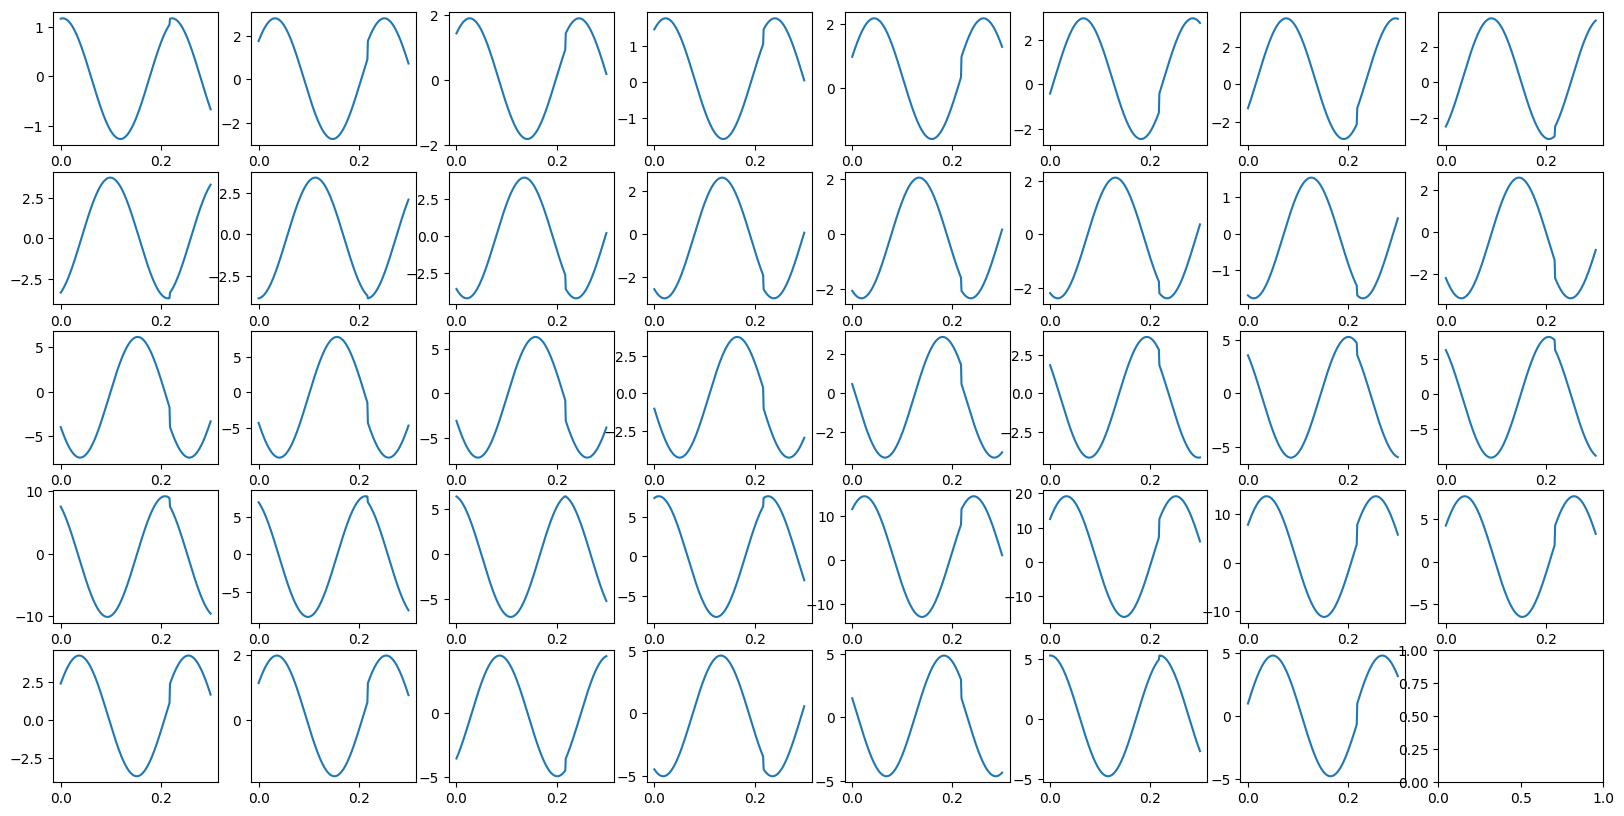

In [10]:
tclip = 300
fig, axs = plt.subplots(5,8,figsize=(20,10))
for i in range(39):
    ax = axs[i//8, i%8]
    ax.plot(data[:tclip,0], data[:tclip,i+1])

Saved smoothed data to general_swim_extended_sine_fit.csv


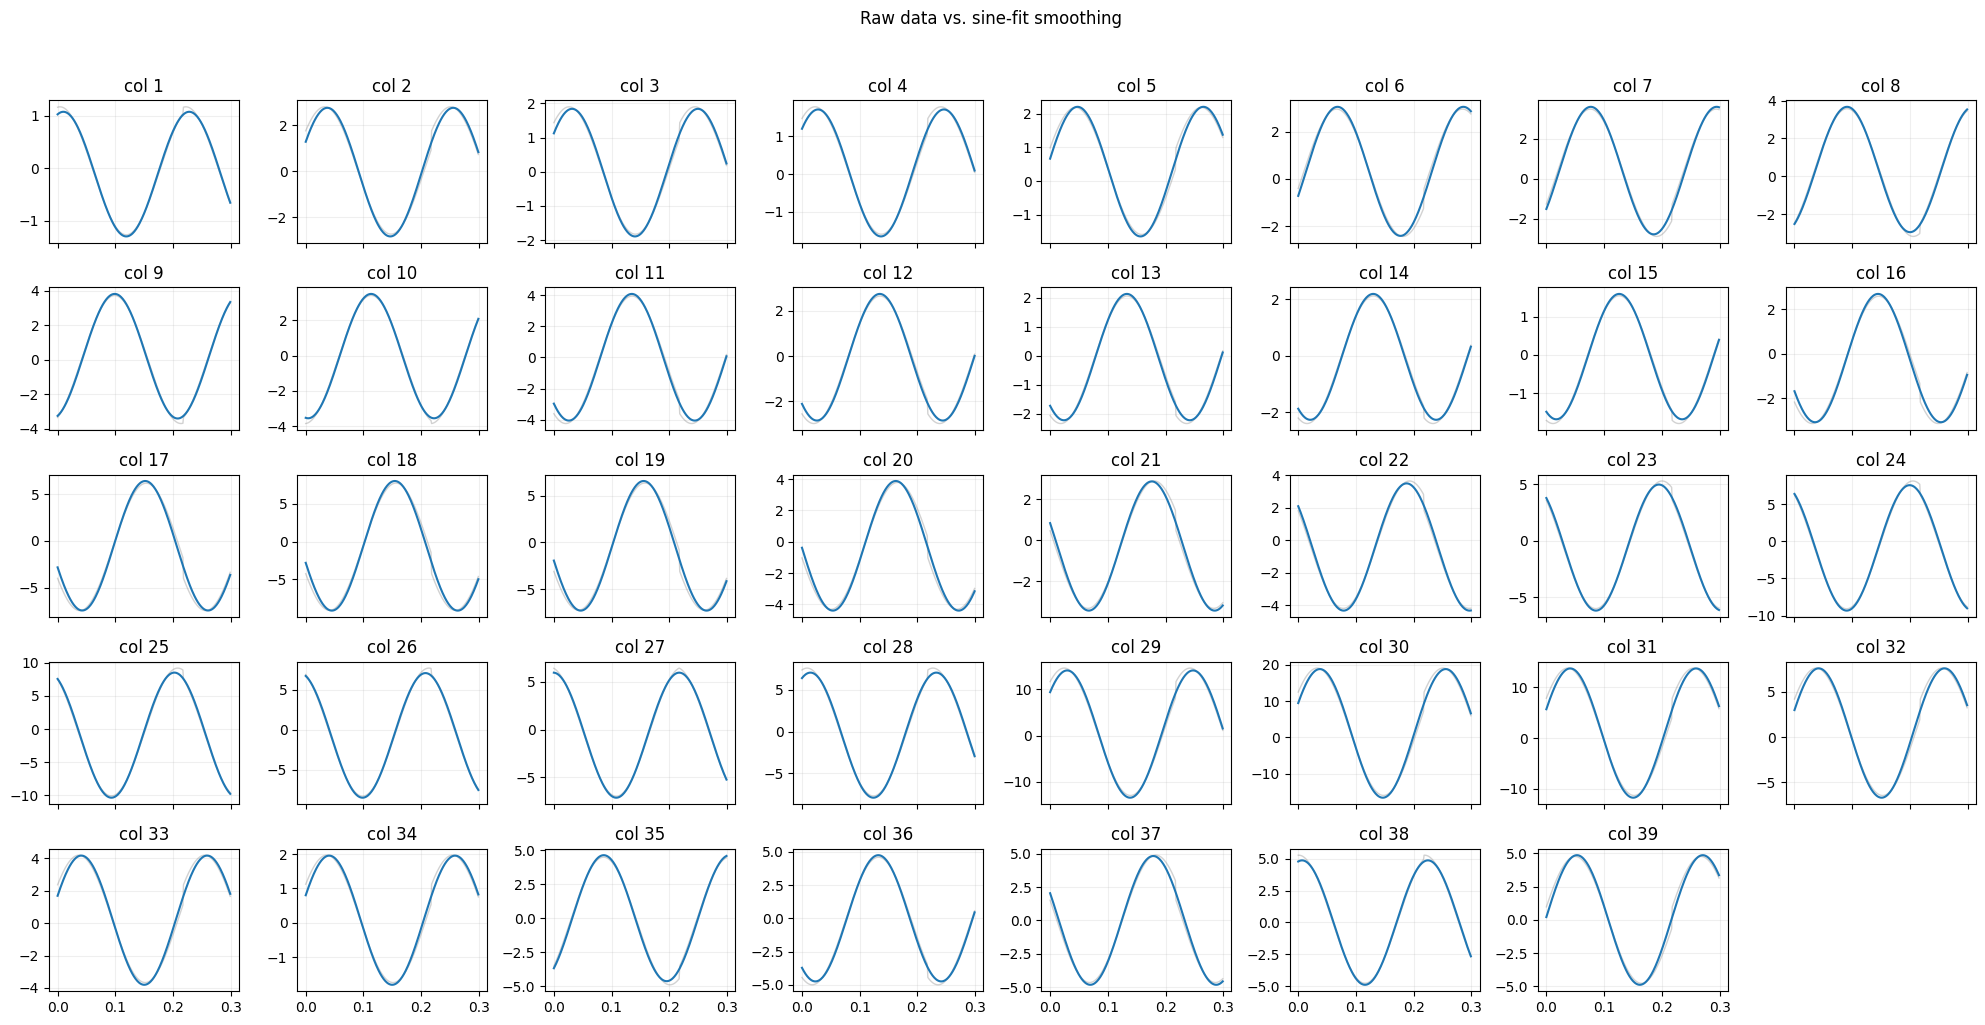

In [11]:
import os

signal = data[:, 1:]
t = data[:, 0]

# Estimate the shared frequency from the dominant spectral peak.
dt = np.median(np.diff(t))
freqs = np.fft.rfftfreq(len(t), d=dt)
centered = signal - np.nanmean(signal, axis=0, keepdims=True)
spectrum = np.abs(np.fft.rfft(centered, axis=0))
mean_power = np.nanmedian(spectrum, axis=1)
mean_power[0] = 0.0
omega = 2 * np.pi * freqs[np.argmax(mean_power)]

processed = data.copy()
fitted = np.empty_like(signal)

for col in range(signal.shape[1]):
    y = signal[:, col]
    mask = np.isfinite(t) & np.isfinite(y)
    design = np.column_stack([
        np.sin(omega * t[mask]),
        np.cos(omega * t[mask]),
        np.ones(mask.sum()),
    ])
    coef, *_ = np.linalg.lstsq(design, y[mask], rcond=None)
    residual = y[mask] - design @ coef
    scale = np.median(np.abs(residual - np.median(residual)))
    if scale > 0:
        keep = np.abs(residual) <= 4.0 * 1.4826 * scale
        if keep.sum() >= 3:
            coef, *_ = np.linalg.lstsq(design[keep], y[mask][keep], rcond=None)
    fitted[:, col] = (
        coef[0] * np.sin(omega * t)
        + coef[1] * np.cos(omega * t)
        + coef[2]
    )

processed[:, 1:] = fitted

output_path = os.path.join(os.path.dirname('general_swim_extended.csv'), 'general_swim_extended_sine_fit.csv')
np.savetxt(output_path, processed, delimiter=',')

fig, axs = plt.subplots(5, 8, figsize=(20, 10), sharex=True)
for i in range(39):
    ax = axs[i // 8, i % 8]
    ax.plot(t[:tclip], data[:tclip, i + 1], color='tab:gray', alpha=0.35, linewidth=1)
    ax.plot(t[:tclip], processed[:tclip, i + 1], color='tab:blue', linewidth=1.5)
    ax.set_title(f'col {i + 1}')
    ax.grid(alpha=0.2)

for ax in axs.ravel()[39:]:
    ax.axis('off')

fig.suptitle('Raw data vs. sine-fit smoothing', y=1.02)
fig.tight_layout()
print(f'Saved smoothed data to {output_path}')